# First sanity check: Ensure LASSO we are using with CV is able to fit a simple dataset

In [2]:
import numpy as np
from sklearn.linear_model import LassoCV, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from typing import Tuple, Optional, Dict, Any, List
import matplotlib.pyplot as plt

In [12]:
# --- 1. LASSO FIT ---
def lasso_fit(X, y, 
              cv_folds: int = 5,
                alphas:  int = 5,
                verbose: bool = True,
                lambda_mode: str = "cv",
                fixed_lambda: Optional[float] = None, 
                standardize: bool = True,
                max_iter: int = 2000) -> Dict[str, Any]:
    
    # Standardize data
    if standardize:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        scaler = None
        X_scaled = X
    if lambda_mode == "cv":
        model = LassoCV(
            cv=5,
            max_iter=max_iter,
            alphas=alphas,
            fit_intercept=False,
            random_state=42
        )
    else:
        model = Lasso(
            alpha=float(fixed_lambda),
            max_iter=2000,
            fit_intercept=False,
            random_state=42
        )
    
    model.fit(X_scaled, y)
    
    # Store Lasso results
    chosen_alpha = float(model.alpha_) if lambda_mode == "cv" else float(fixed_lambda)
    results_data = {
        'model': model,
        'lambdas': [],
        'intercepts': [],
        'insample_r_squareds': [],
        'coefficients': []
    }
    results_data['lambdas'].append(chosen_alpha)
    results_data['intercepts'].append(model.intercept_)
    results_data['insample_r_squareds'].append(model.score(X, y))
    # Transform coefficients back to original scale
    coef = model.coef_ / scaler.scale_ if standardize else model.coef_
    results_data['coefficients'].append(coef)
    return results_data

## Testing the function

In [4]:
def generate_synthetic_data(n_samples: int, n_features: int, n_informative: int, noise: float = 0.1, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X = np.random.randn(n_samples, n_features)
    coef = np.zeros(n_features)
    coef[:n_informative] = np.random.randn(n_informative)
    beta = coef.copy()
    y = X @ coef + noise * np.random.randn(n_samples)
    return X, y, beta

In [5]:
# Try with low noise
X, y, beta = generate_synthetic_data(n_samples=100, n_features=100, n_informative=5, noise=0.1)
results = lasso_fit(X, y, cv_folds=5, lambda_mode="cv")
print("Chosen lambda (low noise):", results['lambdas'][-1])
#check if the parameters are close to the true ones
print("In-sample R^2 (low noise):", results['insample_r_squareds'][-1])
#distance between true and estimated coefficients
np.sum((results['coefficients'][-1] - beta)**2)




Chosen lambda (low noise): 0.033290644810005474
In-sample R^2 (low noise): 0.9883016272022442


np.float64(0.007875308580812833)

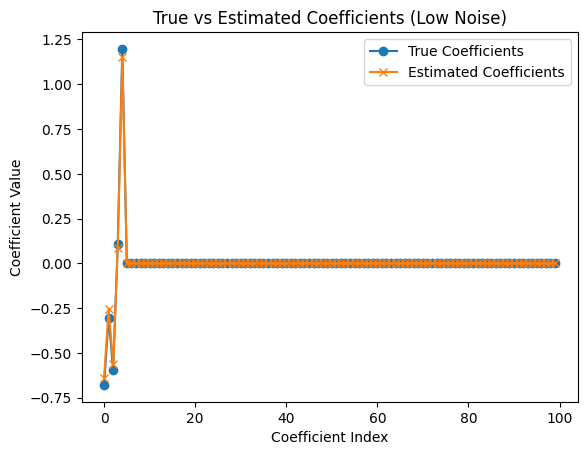

In [6]:
#visualize true vs estimated coefficientsplt.figure(figsize=(10, 6))
plt.plot(beta, label='True Coefficients', marker='o')
plt.plot(results['coefficients'][-1], label='Estimated Coefficients', marker='x')
plt.legend()
plt.title('True vs Estimated Coefficients (Low Noise)')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.show()

In [7]:
#High noise environment
X, y, beta = generate_synthetic_data(n_samples=100, n_features=100, n_informative=5, noise=1.0)
results = lasso_fit(X, y, cv_folds=5, lambda_mode="cv")
print("Chosen lambda (high noise):", results['lambdas'][-1])
#check if the parameters are close to the true ones
print("In-sample R^2 (high noise):", results['insample_r_squareds'][-1])
#distance between true and estimated coefficients   
np.sum((results['coefficients'][-1] - beta)**2)

Chosen lambda (high noise): 0.17590106151235133
In-sample R^2 (high noise): 0.6364973080048362


np.float64(0.3163614433158232)

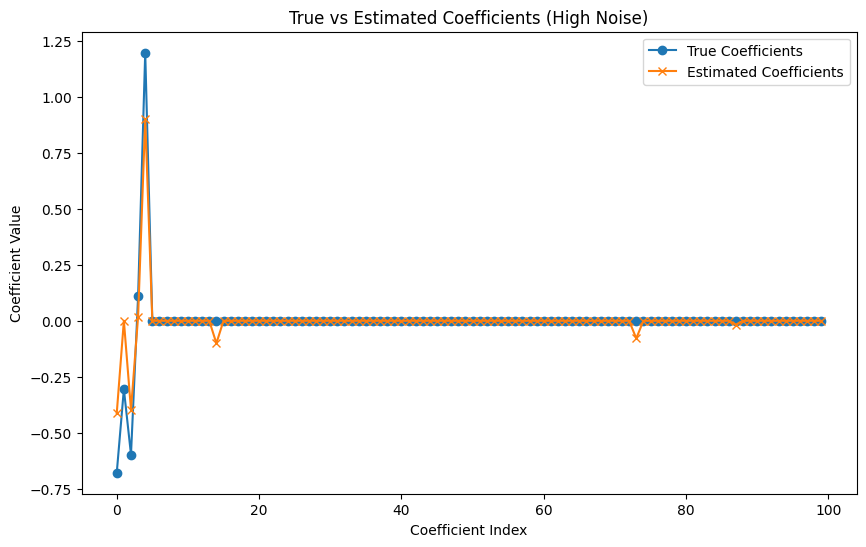

In [8]:
#visualization of coefficients
plt.figure(figsize=(10, 6))
plt.plot(beta, label='True Coefficients', marker='o')
plt.plot(results['coefficients'][-1], label='Estimated Coefficients', marker='x')
plt.legend()
plt.title('True vs Estimated Coefficients (High Noise)')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.show()

In [ ]:
# Sanity check: Lasso when there is no signal (all coefficients are zero)
X, y, beta = generate_synthetic_data(n_samples=100, n_features=100, n_informative=0, noise=0.1)
results = lasso_fit(X, y, cv_folds=5, lambda_mode="cv", max_iter = 1000)
print("Chosen lambda (no signal):", results['lambdas'][-1])
print("In-sample R^2 (no signal):", results['insample_r_squareds'][-1])

Chosen lambda (no signal): 0.02453672301438124
In-sample R^2 (no signal): -7.50759669805312e-05
